<h1 style="margin-bottom: 0; text-align:center">
<b>
<font color="problue">
    AI61006 • <a href='https://prabhatkmishra.github.io/cps.html' style="color: inherit; text-decoration: none;" onmouseover="this.style.textDecoration='underline'" onmouseout="this.style.textDecoration='none'">AI for Cyber Physical Systems</a>
</font>
</b>
</h1>
<h2 style="margin-top: 0; text-align:center"><b>Spring 2026</b></h2>
<h4 style="text-align:center">
    Instructor: <a href='https://prabhatkmishra.github.io/people.html' style="color: inherit; text-decoration: none;" onmouseover="this.style.textDecoration='underline'" onmouseout="this.style.textDecoration='none'"><b>Dr. Prabhat Kumar Mishra</b></a> <br>
    TA: <a href='https://in.linkedin.com/in/sekhar07' style="color: inherit; text-decoration: none;" onmouseover="this.style.textDecoration='underline'" onmouseout="this.style.textDecoration='none'"><b>Ankam Solomon Surya Sekhar</b></a>
</h4>

---

<h1 style="text-align:center; font-weight: bold">Tutorial 4 &bull; REINFORCE</h1>

---

In this notebook, we will train REINFORCE with OpenAI Gym's Cartpole environment.

### 1. Import the Necessary Packages

In [8]:
pip install numpy matplotlib torch gymnasium "gymnasium[classic-control] 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import gymnasium as gym
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

### 2. Define the Architecture of the Policy

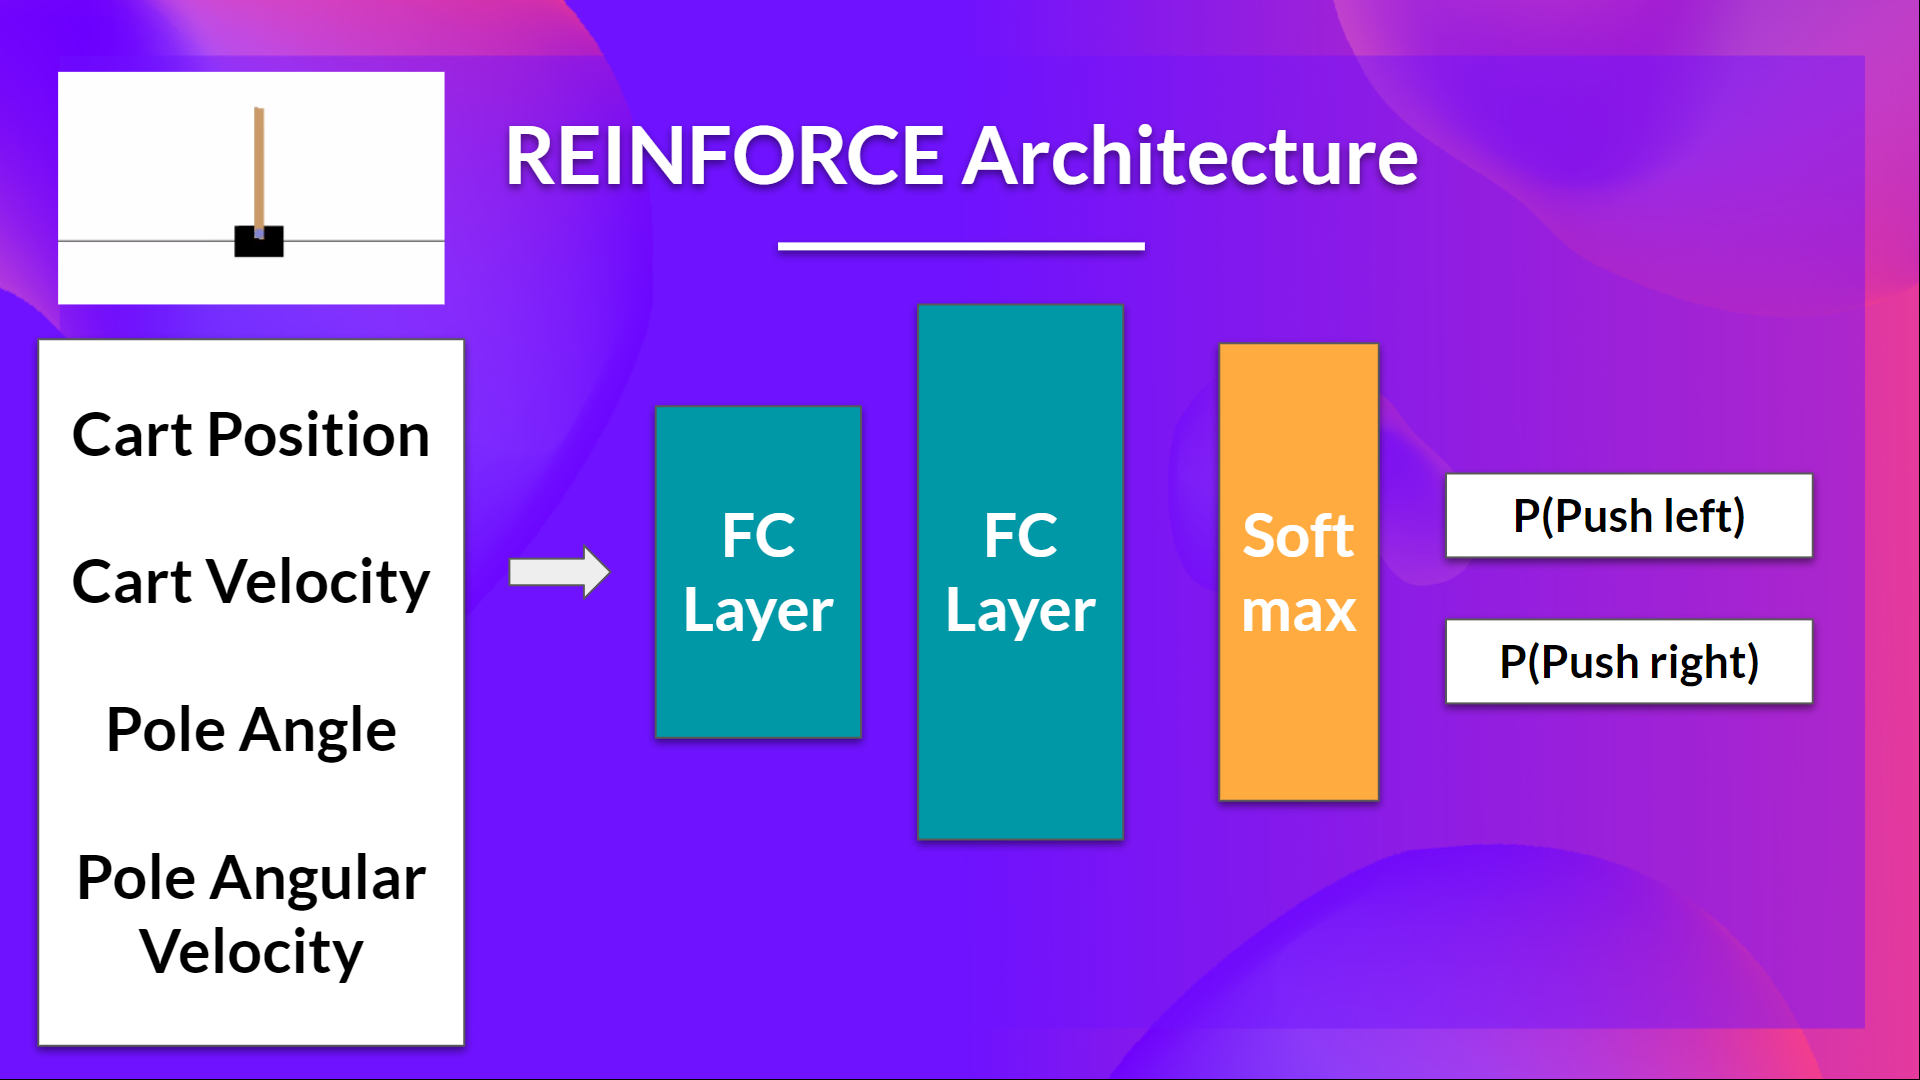

In [3]:
env = gym.make("CartPole-v1")

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)


In [4]:
class Policy(nn.Module):

    def __init__(self, state_size=4, hidden_size=16, action_size=2):
        super().__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, action_size)
        # Input layer: 4
        # Hidden layer: 16
        # Output layer: 2

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return torch.softmax(x, dim=1)

    def act(self, state):
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        probs = self.forward(state)
        dist = Categorical(probs)
        action = dist.sample()

        return action.item(), dist.log_prob(action)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


### 3. Train the Agent with REINFORCE

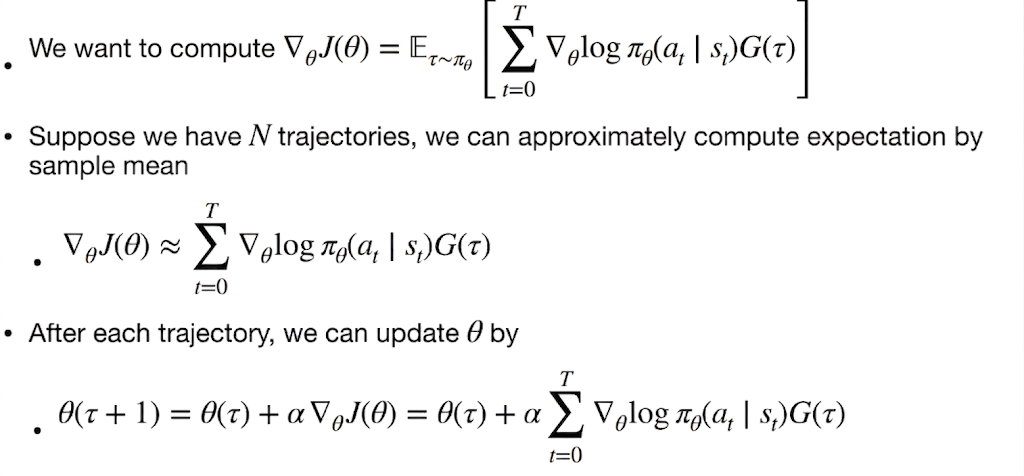

In [6]:
policy = Policy().to(device)
optimizer = optim.Adam(policy.parameters(), lr=1e-2)


def reinforce(policy, optimizer, n_episodes=2000, max_t=1000, gamma=1.0, print_every=100):

    scores_deque = deque(maxlen=100)
    scores = []

    for i_episode in range(1, n_episodes + 1): # loop through N episodes
        saved_log_probs = []
        rewards = []
        state, _ = env.reset() # intialize the environment or reset 
        
        for t in range(max_t): #loop or steps
            action, log_prob = policy.act(state)   # choose action from policy
            saved_log_probs.append(log_prob)       # store log probability
            # gymnasium step
            state, reward, terminated, truncated, _ = env.step(action) # perform action
            done = terminated or truncated
            rewards.append(reward)
            if done:
                break

        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # compute episode return 
        discounts = [gamma ** i for i in range(len(rewards))]
        R = sum([a * b for a, b in zip(discounts, rewards)])

        #TODO 
        # write the code for per step return
        # Also normalize the returns

        # compute policy loss
        policy_loss = []
        for log_prob in saved_log_probs:
            policy_loss.append(-log_prob * R)
        policy_loss = torch.stack(policy_loss).sum() # compute policy loss
        optimizer.zero_grad()   # clears old gradients since they accumulate
        policy_loss.backward()  # backpropogate
        optimizer.step()        # update the network

        if i_episode % print_every == 0:
            print(f"Episode {i_episode}\tAverage Score: {np.mean(scores_deque):.2f}")

    return scores

scores = reinforce(policy, optimizer)

Episode 100	Average Score: 23.53
Episode 200	Average Score: 34.27
Episode 300	Average Score: 80.89
Episode 400	Average Score: 90.03
Episode 500	Average Score: 80.17
Episode 600	Average Score: 78.67
Episode 700	Average Score: 145.92
Episode 800	Average Score: 136.06
Episode 900	Average Score: 124.63
Episode 1000	Average Score: 139.90


KeyboardInterrupt: 

### 4. Plot the Scores

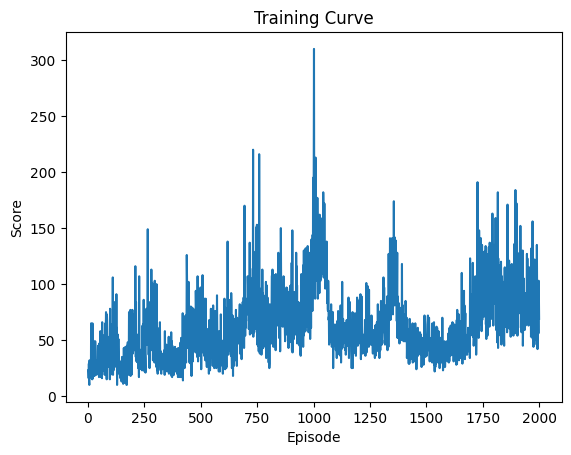

In [6]:
plt.plot(np.arange(1, len(scores)+1), scores)
plt.xlabel("Episode")
plt.ylabel("Score")
plt.title("Training Curve")
plt.show()

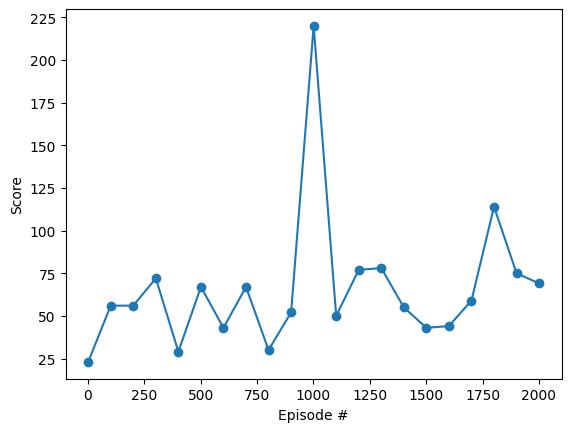

In [7]:
plt.plot(np.append(np.arange(1, len(scores)+1, 100),2001), np.append(scores[::100],scores[-1]), marker='o')
plt.ylabel('Score')
plt.xlabel('Episode #')
plt.show()

### 5. Watch a Smart Agent!

In [8]:
import time

In [ ]:
env = gym.make("CartPole-v1", render_mode="human")

state, _ = env.reset()

for t in range(1000):
    action, _ = policy.act(state)
    state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    time.sleep(0.03)
    if done:
        print("Episode finished after", t, "steps")
        break

In [12]:
env.close()